In [8]:
import pandas as pd
import numpy as np

# ========== Load and Parse the Data ==========
df = pd.read_csv("floor2-zone1_with_weather.csv", parse_dates=['Timestamp'])
df.set_index('Timestamp', inplace=True)
df.sort_index(inplace=True)

# ========== Time-based Features ==========
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['weekday'] = df.index.dayofweek
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# ========== Lag Features (Autoregression) ==========
df['temp_lag_1'] = df['z1_S1(degC)'].shift(1)
df['temp_lag_2'] = df['z1_S1(degC)'].shift(2)

# ========== Rolling Statistics (Short-term Trend) ==========
df['temp_roll_min_30'] = df['z1_S1(degC)'].rolling(30).min()

# ========== AC and Interaction Features ==========
df['ac_on'] = (df['z1_AC1(kW)'] > 0.1).astype(int)
df['temp_diff'] = df['z1_S1(degC)'] - df['Temperature']
df['ac_temp_diff'] = df['z1_AC1(kW)'] * df['temp_diff']

# ========== Target Variable: 1-hour Ahead Indoor Temperature ==========
# Assuming 1 sample = 2 minutes → 30 samples ≈ 1 hour
df['target'] = df['z1_S1(degC)'].shift(-30)

# ========== Drop Rows with Missing Values ==========
df.dropna(inplace=True)

# ========== Final Feature List ==========
final_columns = [
    'z1_S1(degC)',         # Indoor temperature (current)
    'temp_lag_1',
    'temp_lag_2',
    'z1_AC1(kW)',          # AC power
    'ac_on',
    'ac_temp_diff',
    'Temperature',         # Outdoor temp
    'temp_diff',
    'hour', 'hour_sin', 'hour_cos',
    'weekday', 'is_weekend',
    'temp_roll_min_30',
    'target'               # 1-hour ahead indoor temperature
]

df_final = df[final_columns]

# ========== Save to CSV (Optional) ==========
df_final.to_csv("feature_engineered_indoor_temp.csv")

# Preview
print(df_final.head())


                     z1_S1(degC)  temp_lag_1  temp_lag_2  z1_AC1(kW)  ac_on  \
Timestamp                                                                     
2018-07-01 00:29:00        28.39       28.39       28.39         0.0      0   
2018-07-01 00:30:00        28.39       28.39       28.39         0.0      0   
2018-07-01 00:31:00        28.39       28.39       28.39         0.0      0   
2018-07-01 00:32:00        28.39       28.39       28.39         0.0      0   
2018-07-01 00:33:00        28.39       28.39       28.39         0.0      0   

                     ac_temp_diff  Temperature  temp_diff  hour  hour_sin  \
Timestamp                                                                   
2018-07-01 00:29:00           0.0        25.04       3.35     0       0.0   
2018-07-01 00:30:00           0.0        25.00       3.39     0       0.0   
2018-07-01 00:31:00           0.0        25.00       3.39     0       0.0   
2018-07-01 00:32:00           0.0        25.00       3.39    

✅ Using device: mps


Epoch 100/100 | Loss: 0.0224: 100%|██████████| 100/100 [8:22:39<00:00, 301.59s/it]



📊 Evaluation:
✅ R² Score       : 0.9761
📉 MAE (°C)       : 0.2240
📉 RMSE (°C)      : 0.4243
🎯 Accuracy (±0.5°C): 87.91%


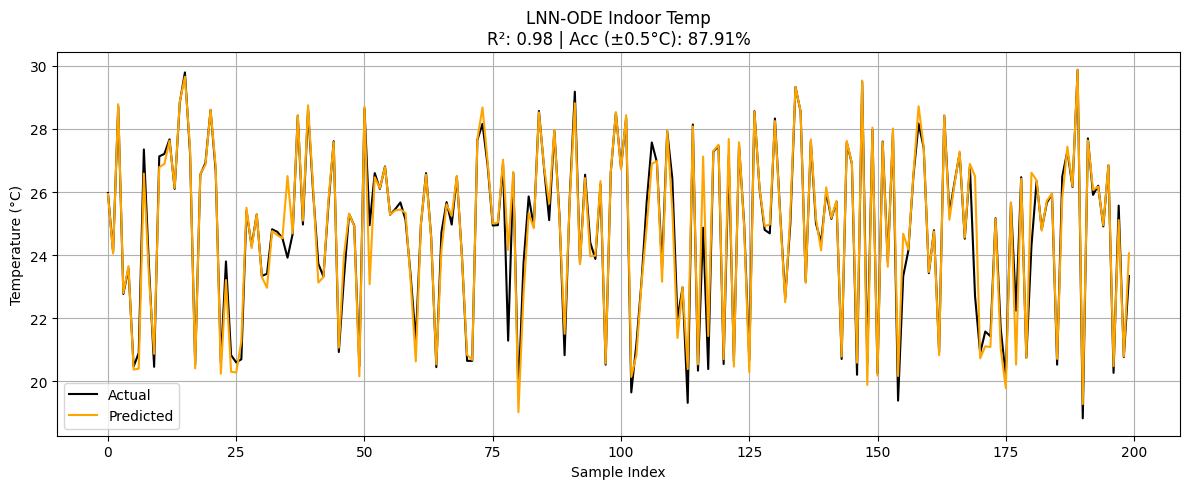

✅ Model and scalers saved in: lnn_ode_model/


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchdiffeq import odeint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import os
import joblib

# ========= DEVICE SETUP =========
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Using device: {device}")

# ========= Load and Scale Data =========
df = pd.read_csv("feature_engineered_indoor_temp.csv", index_col="Timestamp")
X = df.drop(columns=["target"]).values
y = df["target"].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X).astype(np.float32)
y_scaled = scaler_y.fit_transform(y).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# ========= Convert to Tensors =========
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# ========= Create DataLoader for Batching =========
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ========= Liquid ODE Function =========
class LNN_ODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.act = nn.Tanh()

    def forward(self, t, h):
        combined = torch.cat([self.inp_expand, h], dim=1)
        return self.act(self.norm(self.linear(combined)))

# ========= ODE Block =========
# Updated ODEBlock
class LNN_ODEBlock(nn.Module):
    def __init__(self, odefunc):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0., 1.], dtype=torch.float32)

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        h0 = torch.zeros(x.size(0), self.odefunc.linear.out_features, device=x.device, dtype=torch.float32)
        self.odefunc.inp_expand = x
        t = self.integration_time.to(x.device)

        # === WORKAROUND: Use float32 + force internal solver to avoid float64
        h_out = odeint(
            self.odefunc,
            h0,
            t,
            rtol=1e-3,
            atol=1e-4,
            method='dopri5',
            options={'dtype': torch.float32}  # ✅ FORCE float32 inside torchdiffeq solver
        )[-1]

        return h_out

# ========= LNN-ODE Model =========
class LiquidNeuralODE(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.odefunc = LNN_ODEFunc(input_dim, hidden_dim)
        self.odeblock = LNN_ODEBlock(self.odefunc)
        self.readout = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.readout(self.odeblock(x))

# ========= Initialize Model =========
model = LiquidNeuralODE(input_dim=X.shape[1], hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# ========= Train with Batches =========
n_epochs = 100
progress = trange(n_epochs, desc="Training")
model.train()

for epoch in progress:
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    progress.set_description(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

# ========= Evaluate =========
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy()
    y_pred_actual = scaler_y.inverse_transform(y_pred_test)
    y_test_actual = scaler_y.inverse_transform(y_test_tensor.cpu().numpy())

r2 = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
accuracy = np.mean(np.abs(y_pred_actual - y_test_actual) <= 0.5) * 100

print(f"\n📊 Evaluation:")
print(f"✅ R² Score       : {r2:.4f}")
print(f"📉 MAE (°C)       : {mae:.4f}")
print(f"📉 RMSE (°C)      : {rmse:.4f}")
print(f"🎯 Accuracy (±0.5°C): {accuracy:.2f}%")

# ========= Plot Results =========
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200], label="Actual", color='blue')
plt.plot(y_pred_actual[:200], label="Predicted", color='orange')
plt.title(f"LNN-ODE Indoor Temp\nR²: {r2:.2f} | Acc (±0.5°C): {accuracy:.2f}%")
plt.xlabel("Sample Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========= Save Model and Scalers =========
os.makedirs("lnn_ode_model", exist_ok=True)
torch.save(model.state_dict(), "lnn_ode_model/lnn_ode.pth")
joblib.dump(scaler_X, "lnn_ode_model/scaler_X.save")
joblib.dump(scaler_y, "lnn_ode_model/scaler_y.save")
print("✅ Model and scalers saved in: lnn_ode_model/")

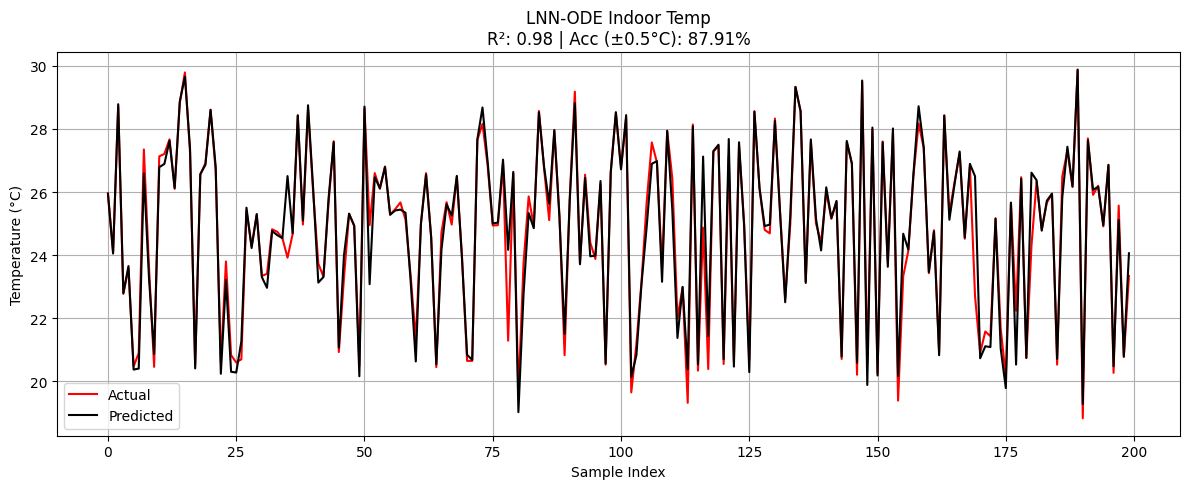

In [15]:
# ========= Plot Results =========
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:200], label="Actual", color='red')
plt.plot(y_pred_actual[:200], label="Predicted", color='black')
plt.title(f"LNN-ODE Indoor Temp\nR²: {r2:.2f} | Acc (±0.5°C): {accuracy:.2f}%")
plt.xlabel("Sample Index")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()